,Dataset,MLP_mean,MLP_std,GCN_mean,GCN_std,GraphSAGE_mean,GraphSAGE_std,GAT_mean,GAT_std,H2GCN_mean,H2GCN_std
0,DE,0.624,0.010,0.673,0.009,0.639,0.011,0.438,0.092,0.639,0.005
1,EN,0.579,0.005,0.604,0.016,0.587,0.020,0.370,0.013,0.593,0.012
2,ES,0.459,0.036,0.600,0.107,0.583,0.016,0.577,0.073,0.418,0.011
3,FR,0.560,0.026,0.628,0.013,0.572,0.016,0.585,0.011,0.549,0.066
4,PT,0.566,0.040,0.638,0.039,0.588,0.029,0.572,0.072,0.497,0.099
5,RU,0.461,0.020,0.460,0.041,0.483,0.008,0.472,0.037,0.460,0.040
6,Average,0.542,0.023,0.601,0.038,0.575,0.017,0.502,0.050,0.526,0.039


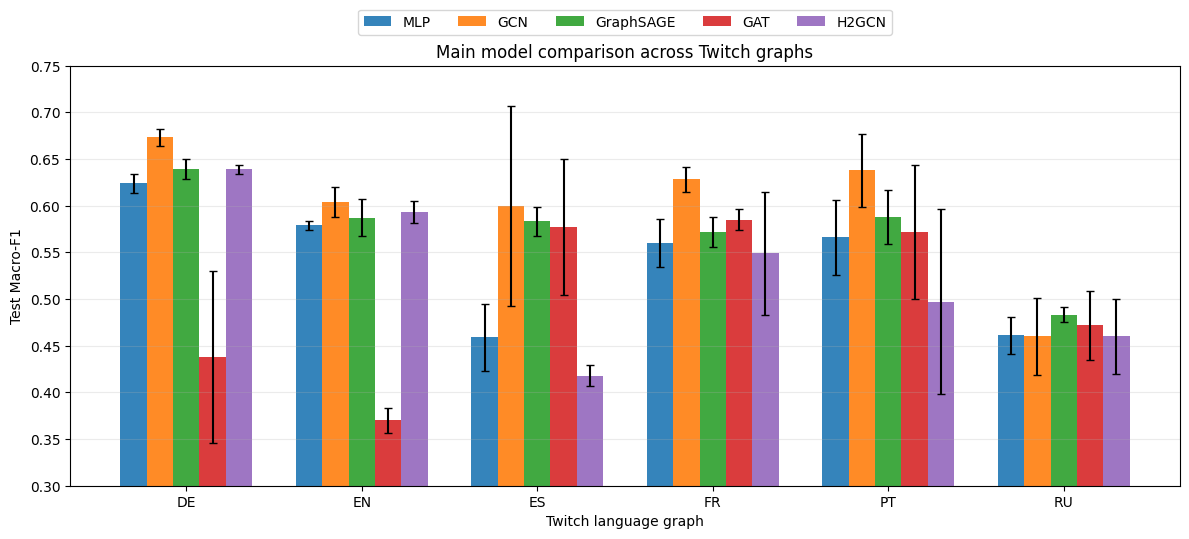

Saved:
figures/main_model_comparison.png
figures/main_model_comparison.pdf


In [1]:
# ============================================================
# Main model comparison plot from table values
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Data from your LaTeX table
# -----------------------------
data = {
    "Dataset": ["DE", "EN", "ES", "FR", "PT", "RU", "Average"],
    "MLP_mean": [0.624, 0.579, 0.459, 0.560, 0.566, 0.461, 0.542],
    "MLP_std":  [0.010, 0.005, 0.036, 0.026, 0.040, 0.020, 0.023],

    "GCN_mean": [0.673, 0.604, 0.600, 0.628, 0.638, 0.460, 0.601],
    "GCN_std":  [0.009, 0.016, 0.107, 0.013, 0.039, 0.041, 0.038],

    "GraphSAGE_mean": [0.639, 0.587, 0.583, 0.572, 0.588, 0.483, 0.575],
    "GraphSAGE_std":  [0.011, 0.020, 0.016, 0.016, 0.029, 0.008, 0.017],

    "GAT_mean": [0.438, 0.370, 0.577, 0.585, 0.572, 0.472, 0.502],
    "GAT_std":  [0.092, 0.013, 0.073, 0.011, 0.072, 0.037, 0.050],

    "H2GCN_mean": [0.639, 0.593, 0.418, 0.549, 0.497, 0.460, 0.526],
    "H2GCN_std":  [0.005, 0.012, 0.011, 0.066, 0.099, 0.040, 0.039],
}

df = pd.DataFrame(data)
display(df)

# -----------------------------
# Output folder
# -----------------------------
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# -----------------------------
# Grouped bar plot with error bars
# -----------------------------
models = ["MLP", "GCN", "GraphSAGE", "GAT", "H2GCN"]

# Usually better to plot only real datasets, not Average
plot_df = df[df["Dataset"] != "Average"].copy()

x = np.arange(len(plot_df["Dataset"]))
width = 0.15

plt.figure(figsize=(12, 5.5))

for i, model in enumerate(models):
    offset = (i - (len(models) - 1) / 2) * width
    means = plot_df[f"{model}_mean"]
    stds = plot_df[f"{model}_std"]

    plt.bar(
        x + offset,
        means,
        width=width,
        yerr=stds,
        capsize=3,
        label=model,
        alpha=0.9
    )

plt.xticks(x, plot_df["Dataset"])
plt.xlabel("Twitch language graph")
plt.ylabel("Test Macro-F1")
plt.title("Main model comparison across Twitch graphs")
plt.ylim(0.30, 0.75)
plt.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.15))
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

png_path = os.path.join(FIGURES_DIR, "main_model_comparison.png")
pdf_path = os.path.join(FIGURES_DIR, "main_model_comparison.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

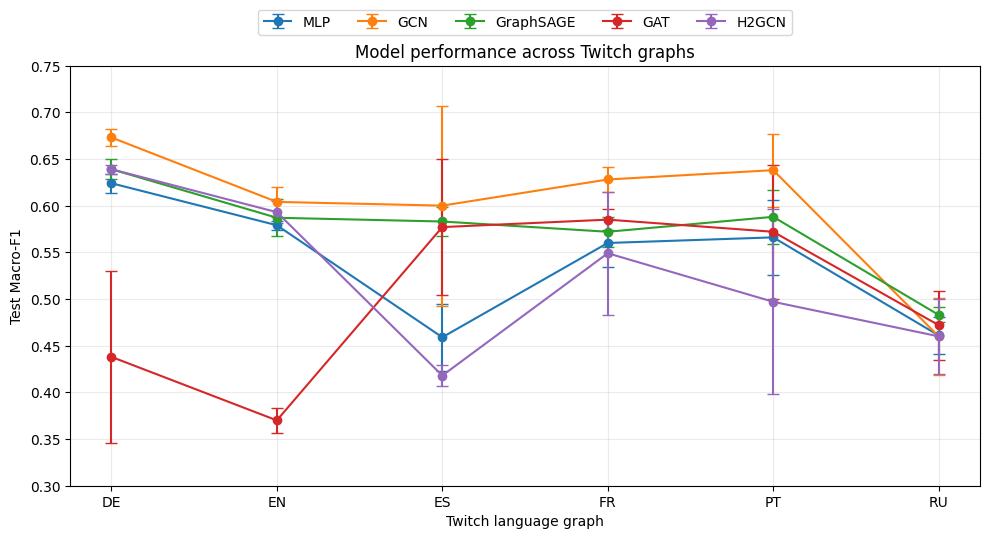

Saved:
figures/main_model_comparison_lines.png
figures/main_model_comparison_lines.pdf


In [2]:
# ============================================================
# Alternative visualization: line plot by model
# Often cleaner than grouped bars when there are 5 models
# ============================================================

plt.figure(figsize=(10, 5.5))

for model in models:
    plt.errorbar(
        plot_df["Dataset"],
        plot_df[f"{model}_mean"],
        yerr=plot_df[f"{model}_std"],
        marker="o",
        capsize=4,
        label=model
    )

plt.xlabel("Twitch language graph")
plt.ylabel("Test Macro-F1")
plt.title("Model performance across Twitch graphs")
plt.ylim(0.30, 0.75)
plt.grid(alpha=0.25)
plt.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.15))
plt.tight_layout()

png_path = os.path.join(FIGURES_DIR, "main_model_comparison_lines.png")
pdf_path = os.path.join(FIGURES_DIR, "main_model_comparison_lines.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)